In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/BreastMNIST_2000"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count}")

normal: 538
malignant: 1462


In [ ]:
# ================= INSTALL =================
!pip install pennylane pennylane-lightning pennylane-qiskit
!pip install torchvision torch torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 

In [ ]:
# ================= IMPORTS =================
import os, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml


In [ ]:
# ================= SETTINGS =================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_ROOT = "/content/drive/MyDrive/BreastMNIST_2000"

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

LEARNING_RATE = 3e-4

N_QUBITS = 4
N_Q_LAYERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ================= TRANSFORM =================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# ================= DATASET =================
dataset_full = datasets.ImageFolder(DATA_ROOT, transform=transform)
classes = dataset_full.classes

targets = np.array([s[1] for s in dataset_full.samples])
idx = np.arange(len(targets))

train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=targets[test_idx], random_state=SEED)

train_dataset = Subset(dataset_full, train_idx)
val_dataset = Subset(dataset_full, val_idx)
test_dataset = Subset(dataset_full, test_idx)


In [ ]:
# ================= SAMPLER =================
train_labels = targets[train_idx]
class_counts = np.bincount(train_labels)
class_weights = {i: 1.0 / c for i, c in enumerate(class_counts)}
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
# ================= TRAIN FUNCTIONS =================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, 100 * correct / total

def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds = model(x).argmax(dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    return accuracy_score(y_true, y_pred) * 100, y_true, y_pred

def print_full_metrics(model, loader, device, name, classes):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)

    print(f"\n===== {name} Metrics =====")
    print(f"Accuracy: {acc:.2f}%\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

In [ ]:
# ================= TRAIN WITH TIME =================
def train_with_time(model, train_loader, val_loader, optimizer, criterion, device, epochs, tag="Model"):
    start_total = time.time()

    epoch_times = []
    train_acc_hist = []
    val_acc_hist = []
    train_loss_hist = []

    for epoch in range(epochs):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_acc, _, _ = evaluate(model, val_loader, device)

        t1 = time.time()
        epoch_times.append(t1 - t0)

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        train_loss_hist.append(train_loss)

        print(f"[{tag}] Epoch {epoch+1} | Train={train_acc:.2f}% | Val={val_acc:.2f}% | Time={epoch_times[-1]:.2f}s")

    total_time = time.time() - start_total

    print(f"\n[{tag}] TOTAL TRAIN TIME: {total_time:.2f} sec")

    return train_acc_hist, val_acc_hist, train_loss_hist, epoch_times, total_time

In [ ]:
# ================= QNN =================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class QNNAux(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(0.01 * torch.randn(N_Q_LAYERS, N_QUBITS))

    def forward(self, x):
        outputs = []
        for sample in x:
            sample = torch.tanh(sample) * np.pi
            q_out = torch.stack(qnode(sample, self.weights)).float()
            outputs.append(q_out)
        return torch.stack(outputs)

In [ ]:
# ================= MODELS =================
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights

class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = efficientnet_b5(weights=EfficientNet_B5_Weights.DEFAULT)

        self.backbone.classifier[1] = nn.Linear(
            self.backbone.classifier[1].in_features,
            num_classes
        )

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)
        return self.backbone(x)


class HybridEfficientNetQNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        eff = efficientnet_b5(weights=EfficientNet_B5_Weights.DEFAULT)

        self.features = eff.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.projector = nn.Sequential(
            nn.Linear(2048, 128),
            nn.ReLU(),
            nn.Linear(128, N_QUBITS)
        )

        self.qnn = QNNAux()

        self.summary = nn.Sequential(
            nn.Linear(2048, 32),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(N_QUBITS + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # 🔥 CRITICAL FIX (device sync)
        x = x.to(next(self.parameters()).device)

        x = x.repeat(1, 3, 1, 1)

        feat = self.pool(self.features(x)).flatten(1)

        q_out = self.qnn(self.projector(feat))
        summary = self.summary(feat)

        return self.classifier(torch.cat([q_out, summary], dim=1))

In [ ]:
# ================= TRAIN BASELINE =================
baseline = EfficientNetClassifier(len(classes)).to(DEVICE)
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

eff_train_acc, eff_val_acc, eff_loss, eff_times, eff_total = train_with_time(
    baseline, train_loader, val_loader, optimizer, criterion, DEVICE, 10, "EffNet-B5"
)

[EffNet-B5] Epoch 1 | Train=80.88% | Val=74.00% | Time=287.92s
[EffNet-B5] Epoch 2 | Train=91.44% | Val=82.00% | Time=165.93s
[EffNet-B5] Epoch 3 | Train=95.75% | Val=79.50% | Time=97.34s
[EffNet-B5] Epoch 4 | Train=96.69% | Val=80.50% | Time=75.93s
[EffNet-B5] Epoch 5 | Train=97.44% | Val=86.50% | Time=59.25s
[EffNet-B5] Epoch 6 | Train=97.31% | Val=89.50% | Time=49.85s
[EffNet-B5] Epoch 7 | Train=98.12% | Val=86.50% | Time=43.97s
[EffNet-B5] Epoch 8 | Train=97.19% | Val=88.00% | Time=42.27s
[EffNet-B5] Epoch 9 | Train=98.75% | Val=89.50% | Time=43.96s
[EffNet-B5] Epoch 10 | Train=98.88% | Val=88.50% | Time=41.14s

[EffNet-B5] TOTAL TRAIN TIME: 907.56 sec


In [ ]:
# ================= HYBRID =================
hybrid = HybridEfficientNetQNN(len(classes)).to(DEVICE)

optimizer = optim.Adam(hybrid.parameters(), lr=LEARNING_RATE)

hyb_train_acc, hyb_val_acc, hyb_loss, hyb_times, hyb_total = train_with_time(
    hybrid,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    DEVICE,   # 🔥 GPU FIX
    10,
    "Hybrid QNN"
)

[Hybrid QNN] Epoch 1 | Train=77.44% | Val=72.50% | Time=78.64s
[Hybrid QNN] Epoch 2 | Train=91.12% | Val=80.00% | Time=80.06s
[Hybrid QNN] Epoch 3 | Train=93.62% | Val=80.50% | Time=80.13s
[Hybrid QNN] Epoch 4 | Train=95.50% | Val=84.00% | Time=79.20s
[Hybrid QNN] Epoch 5 | Train=95.81% | Val=86.00% | Time=79.27s
[Hybrid QNN] Epoch 6 | Train=97.38% | Val=88.50% | Time=79.09s
[Hybrid QNN] Epoch 7 | Train=98.31% | Val=88.50% | Time=79.39s
[Hybrid QNN] Epoch 8 | Train=98.50% | Val=85.00% | Time=78.59s
[Hybrid QNN] Epoch 9 | Train=98.75% | Val=85.50% | Time=79.56s
[Hybrid QNN] Epoch 10 | Train=98.50% | Val=84.50% | Time=79.32s

[Hybrid QNN] TOTAL TRAIN TIME: 793.26 sec


In [ ]:
# ================= INFERENCE =================
def measure_inference_time(model, loader, device, name):
    model.eval()
    times = []

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i == 30:
                break

            x = x.to(device)

            t0 = time.time()
            _ = model(x)
            t1 = time.time()

            times.append(t1 - t0)

    avg = sum(times) / len(times)
    per_img = avg / loader.batch_size

    print(f"{name} → {per_img:.6f} sec/image")
    return per_img


# ✅ BOTH SHOULD USE DEVICE
eff_inf = measure_inference_time(baseline, test_loader, DEVICE, "EffNet-B5")
hyb_inf = measure_inference_time(hybrid, test_loader, DEVICE, "Hybrid QNN")

EffNet-B5 → 0.001648 sec/image
Hybrid QNN → 0.015180 sec/image


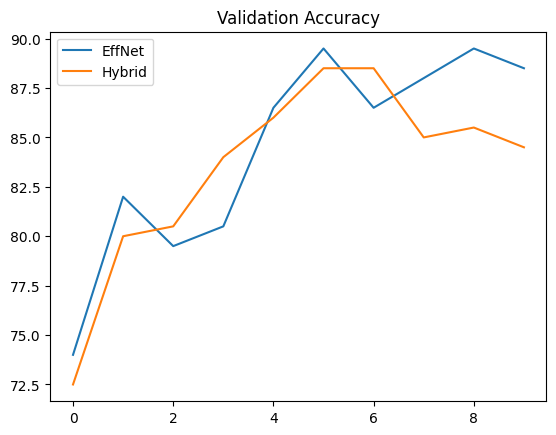

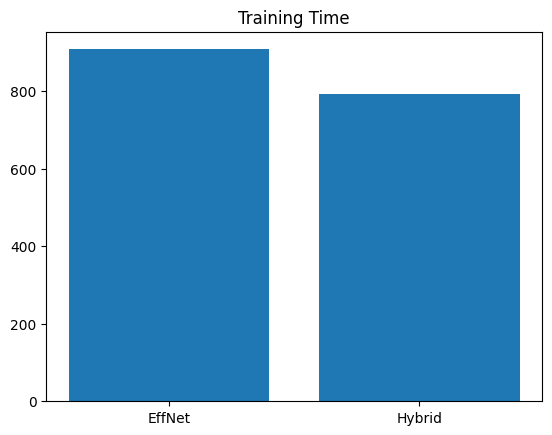

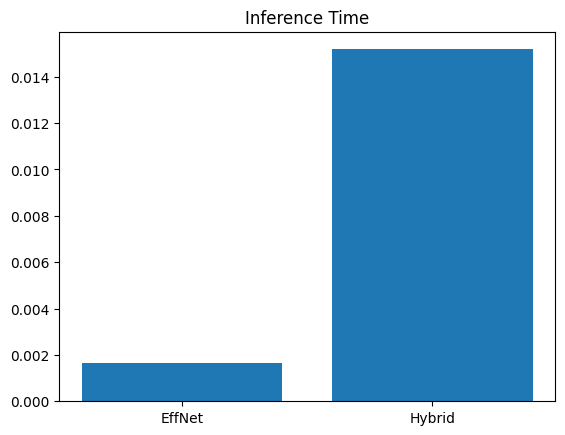

In [ ]:
# ================= GRAPHS =================
plt.plot(eff_val_acc, label="EffNet")
plt.plot(hyb_val_acc, label="Hybrid")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

plt.bar(["EffNet", "Hybrid"], [eff_total, hyb_total])
plt.title("Training Time")
plt.show()

plt.bar(["EffNet", "Hybrid"], [eff_inf, hyb_inf])
plt.title("Inference Time")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, device, classes, title):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,5))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def print_metrics(model, loader, device, name, classes):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n===== {name} Metrics =====")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

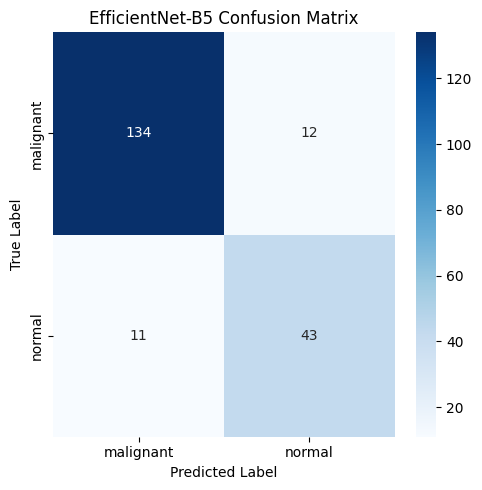

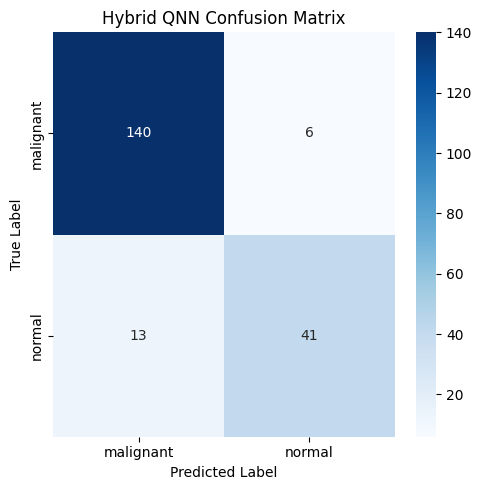

In [ ]:
plot_confusion_matrix(baseline, test_loader, DEVICE, classes, "EfficientNet-B5 Confusion Matrix")

plot_confusion_matrix(hybrid, test_loader, DEVICE, classes, "Hybrid QNN Confusion Matrix")

In [ ]:
# Metrics
print_metrics(baseline, test_loader, DEVICE, "EfficientNet-B5", classes)
print_metrics(hybrid, test_loader, DEVICE, "Hybrid QNN", classes)



===== EfficientNet-B5 Metrics =====
Accuracy : 88.50%
Precision: 0.7818
Recall   : 0.7963
F1-score : 0.7890

Classification Report:
              precision    recall  f1-score   support

   malignant       0.92      0.92      0.92       146
      normal       0.78      0.80      0.79        54

    accuracy                           0.89       200
   macro avg       0.85      0.86      0.85       200
weighted avg       0.89      0.89      0.89       200


===== Hybrid QNN Metrics =====
Accuracy : 90.50%
Precision: 0.8723
Recall   : 0.7593
F1-score : 0.8119

Classification Report:
              precision    recall  f1-score   support

   malignant       0.92      0.96      0.94       146
      normal       0.87      0.76      0.81        54

    accuracy                           0.91       200
   macro avg       0.89      0.86      0.87       200
weighted avg       0.90      0.91      0.90       200



In [ ]:
eff_acc, _, _ = evaluate(baseline, test_loader, DEVICE)
print(f"EfficientNet-B5 Test Accuracy: {eff_acc:.2f}%")

hyb_acc, _, _ = evaluate(hybrid, test_loader, DEVICE)
print(f"Hybrid QNN Test Accuracy: {hyb_acc:.2f}%")

EfficientNet-B5 Test Accuracy: 88.50%
Hybrid QNN Test Accuracy: 90.50%
